In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from seaborn import color_palette
import h5py

from deep_lss.utils import emulator, abc
from msfm.utils import prior, files, parameters

from emcee import EnsembleSampler
from trianglechain import TriangleChain

np.set_printoptions(precision=3)
print(tf.config.list_physical_devices())

23-05-24 07:39:11     utils.py INF   Loaded the config 
23-05-24 07:39:11   kernels.py INF   Setting the minimum value of the kernel function to 1e-42 for the mpmath library 
23-05-24 07:39:11    scales.py INF   Setting up healpy to run on 256 CPUs 
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
conf = files.load_config()

# load the summaries

In [3]:
def load_preds(preds_file):
    with h5py.File(preds_file, "r") as f:
        # fiducial
        fidu_preds = f["fiducial/preds"][:]
        print(f"fidu_preds =        {fidu_preds.shape}")

        # grid
        grid_preds = f["grid/preds"][:]
        grid_cosmos = f["grid/cosmos"][:]
        print(f"grid_preds.shape =  {grid_preds.shape}")
        print(f"grid_cosmos.shape = {grid_cosmos.shape}")
        print(f"\nsingle grid pred example = {grid_preds[0,0]}")

    return fidu_preds, grid_preds, grid_cosmos

In [4]:
# old, lensing only

preds_file = "/pscratch/sd/a/athomsen/run_files/2023-03-13_06-27-46_resnet_small/preds.h5"

fidu_preds, grid_preds, grid_cosmos = load_preds(preds_file)

# only select unique values of Om and s8
grid_cosmos = grid_cosmos[:,0,[2,4]]

print(grid_cosmos.shape)

params = ["Om", "s8"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$']
fiducial = {"Om": 0.26, "s8": 0.84}

fidu_preds =        (800, 2)
grid_preds.shape =  (2500, 16, 2)
grid_cosmos.shape = (2500, 16, 7)

single grid pred example = [0.032 0.078]
(2500, 2)


In [5]:
# probably overfit

preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-15_07-04-57_resnet_vanilla/preds.h5"

fidu_preds, grid_preds, grid_cosmos = load_preds(preds_file)

params = ["Om", "s8", "bg", "n_bg"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_b$']
fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

fidu_preds =        (800, 4)
grid_preds.shape =  (2499, 16, 4)
grid_cosmos.shape = (2499, 4)

single grid pred example = [ 0.373  0.353  0.644 -0.753]


In [6]:
# clustering only, regular evaluation

preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-24_05-18-42_resnet_vanilla/preds_5000.h5"

fidu_preds, grid_preds, grid_cosmos = load_preds(preds_file)

params = ["Om", "s8", "bg", "n_bg"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_b$']
fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

fidu_preds =        (800, 4)
grid_preds.shape =  (2499, 16, 4)
grid_cosmos.shape = (2499, 4)

single grid pred example = [-0.288  0.284 -0.055 -0.304]


In [7]:
# lensing only, regular evaluation

preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-24_05-26-55_resnet_vanilla/preds_5000.h5"

fidu_preds, grid_preds, grid_cosmos = load_preds(preds_file)

params = ["Om", "s8", "bg", "n_bg"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_b$']
fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

fidu_preds =        (800, 4)
grid_preds.shape =  (2499, 16, 4)
grid_cosmos.shape = (2499, 4)

single grid pred example = [ 0.162 -0.014  0.039  0.06 ]


In [8]:
# lensing only, regular evaluation, reduced parameters

preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-24_06-39-40_resnet_vanilla/preds_5000.h5"

fidu_preds, grid_preds, grid_cosmos = load_preds(preds_file)

params = ["Om", "s8"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$']
fiducial = {"Om": 0.26, "s8": 0.84}

fidu_preds =        (800, 2)
grid_preds.shape =  (2499, 16, 2)
grid_cosmos.shape = (2499, 2)

single grid pred example = [0.047 0.087]


### plot the summaries

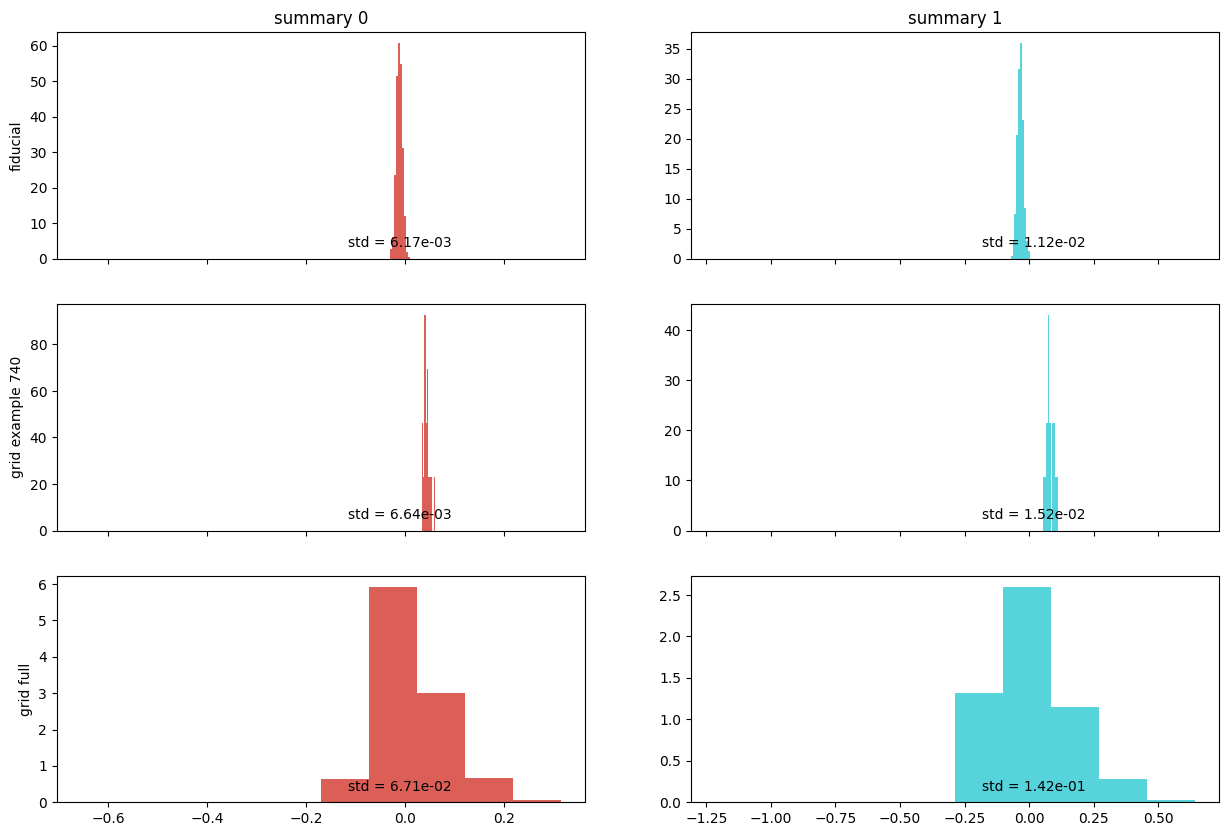

In [9]:
colors = color_palette("hls", n_params)

fig, ax = plt.subplots(nrows=3, ncols=n_params, figsize=(15,10), sharex="col")
# fig, ax = plt.subplots(nrows=3, ncols=n_params, figsize=(10,10))

ax[0,0].set(ylabel="fiducial")
for i in range(n_params):
    preds = fidu_preds[:,i]
    
    ax[0,i].hist(preds, density=True, color=colors[i])
    ax[0,i].set(title=f"summary {i}")
    ax[0,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[0,i].transAxes)

i_example = np.random.randint(grid_preds.shape[0])

ax[1,0].set(ylabel=f"grid example {i_example}")
for i in range(n_params):
    preds = grid_preds[i_example,:,i]
    
    ax[1,i].hist(preds, density=True, color=colors[i])
    ax[1,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[1,i].transAxes)

ax[2,0].set(ylabel="grid full")
for i in range(n_params):
    preds = grid_preds[:,:,i].flatten()
    
    ax[2,i].hist(preds, density=True, color=colors[i])
    ax[2,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[2,i].transAxes)


# Estimate the ABC posterior

### define the observation

In [10]:
# TODO make a distinction between validation and fiducial prediction
obs_pred = np.mean(fidu_preds, axis=0)

### estimate the Fisher matrix

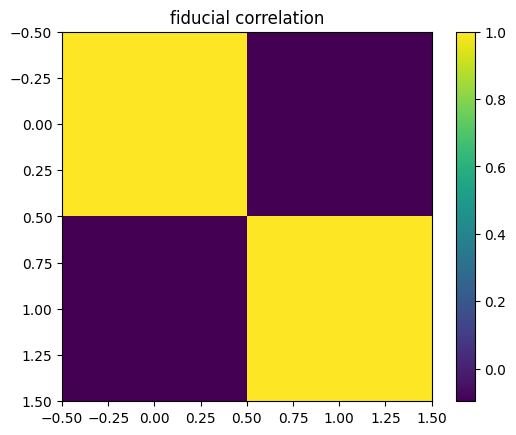

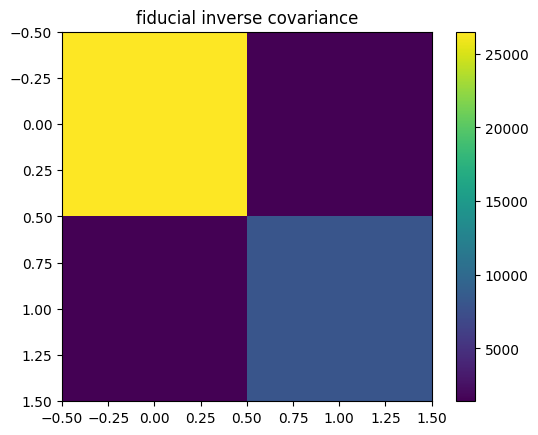

In [11]:
# get an approximation to the Fisher  matrix
fid_cov = np.cov(fidu_preds, rowvar=False)
fid_inv_cov = np.linalg.inv(fid_cov)

plt.imshow(np.corrcoef(fidu_preds, rowvar=False))
plt.colorbar()
plt.title("fiducial correlation")
plt.show()

plt.imshow(fid_inv_cov)
plt.colorbar()
plt.title("fiducial inverse covariance")
plt.show()

### ABC posterior

[Text(0.5, 1.0, 'ABC log posterior variance')]

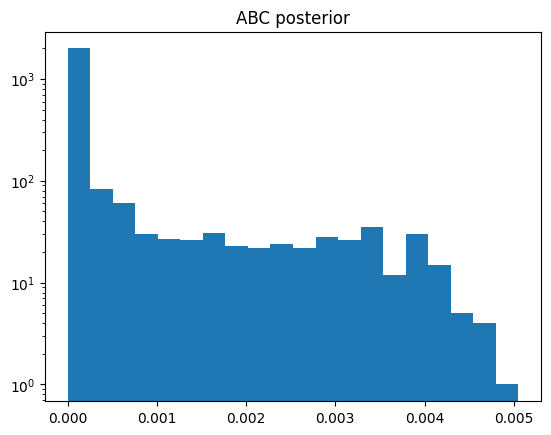

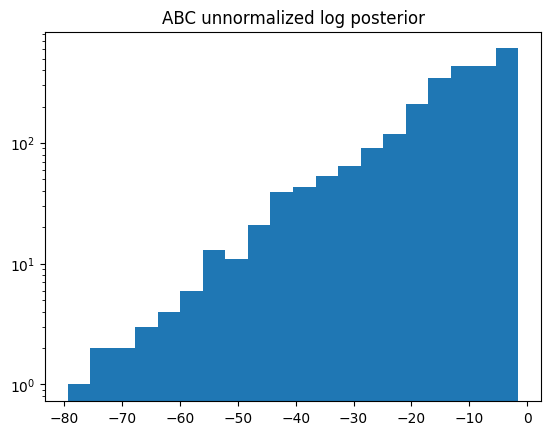

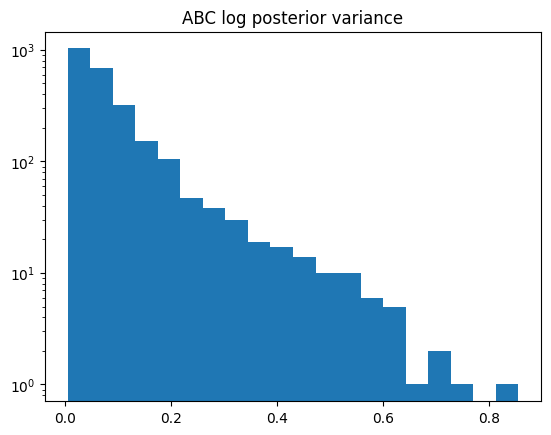

In [12]:
# kernel params
kernel = "sigmoid"
scale = 1.0

# Estimate the posterior and its uncertainties like in the paper
Y_init, abc_posterior = abc.estimate_grid_posterior(
    grid_preds=grid_preds, 
    fid_fisher=fid_inv_cov, 
    obs_pred=obs_pred, 
    scale=scale, 
    kernel=kernel
)

# check posterior
assert np.isclose(np.sum(abc_posterior), 1.0)

fig, ax = plt.subplots()
ax.hist(abc_posterior, log=True, bins=20)
ax.set(title="ABC posterior")

fig, ax = plt.subplots()
ax.hist(Y_init[:,0], log=True, bins=20)
ax.set(title="ABC unnormalized log posterior")

fig, ax = plt.subplots()
ax.hist(Y_init[:,1], log=True, bins=20)
ax.set(title="ABC log posterior variance")

In [13]:
Om = grid_cosmos[:,0]
s8 = grid_cosmos[:,1]

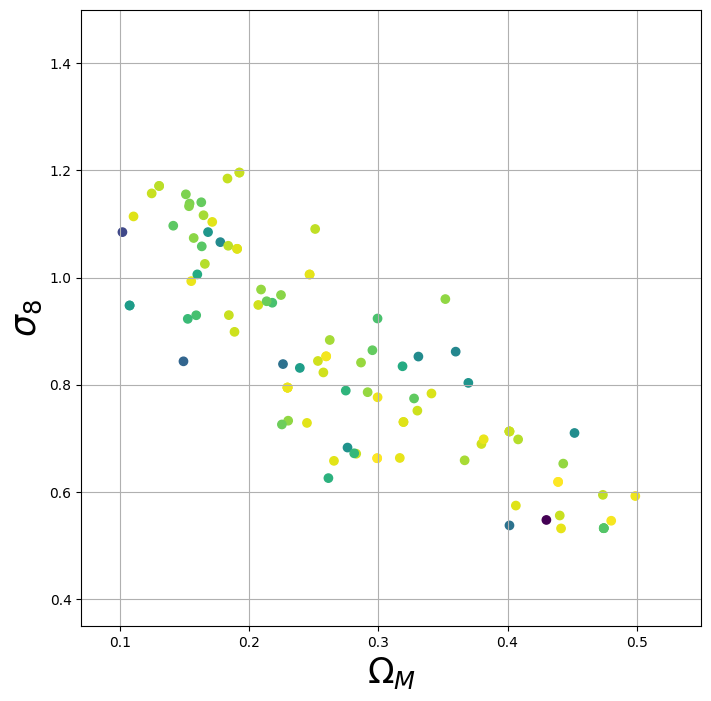

In [14]:
# select a random subset
np.random.seed(11)
probable_indices = np.random.choice(np.arange(len(abc_posterior)), 100, p=abc_posterior, replace=True)

Om_p, s8_p, post_p = Om[probable_indices], s8[probable_indices], abc_posterior[probable_indices],

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(Om_p, s8_p, c=np.log(post_p))
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

# Fit the emulator

In [15]:
X_init = grid_cosmos

# n_grid_points = 1000
# indices = np.random.choice(np.arange(X_init.shape[0]), n_grid_points, replace=False)

# X_init = X_init[indices]
# Y_init = Y_init[indices]

In [16]:
emu = emulator.VGP_Emu(
    X_init=X_init, 
    Y_init=Y_init, 
    kernel_type="squaredexponential", 
    normalize_X=True, 
    normalize_Y=True,
    Y_with_std=True, 
    ARD=True, 
)

2023-05-24 07:39:18.773690: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤══════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value            │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪══════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.0              │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus       │         │ True        │ (2,)            │ float64 │ [1. 1.]          │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.num_data            │ Parameter │ Identity       │         │ False       │ ()              │ int32

2023-05-24 07:39:19.273829: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37125 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:c3:00.0, compute capability: 8.0


In [17]:
emu.repeated_fit(n_steps=1000, n_restarts=1)

  0%|                            |   | 0/1000 [00:00<?, ?it/s]                fit the GP

2023-05-24 07:39:21.760789: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x1d210cb0


100%|████████████████████████████|   | 1000/1000 [01:45<00:00,  9.52it/s, loss_val=6.91e+5] fit the GP
23-05-24 07:41:04  emulator.py INF   Training run 0: loss = 690875.251751068 
23-05-24 07:41:04  emulator.py INF   Training run 0 was best, setting those parameters 
╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤═══════════════════════════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value                                 │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪═══════════════════════════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.07216                               │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼───────────────────────────

### plot the $\Omega_M - \sigma_8$ plane

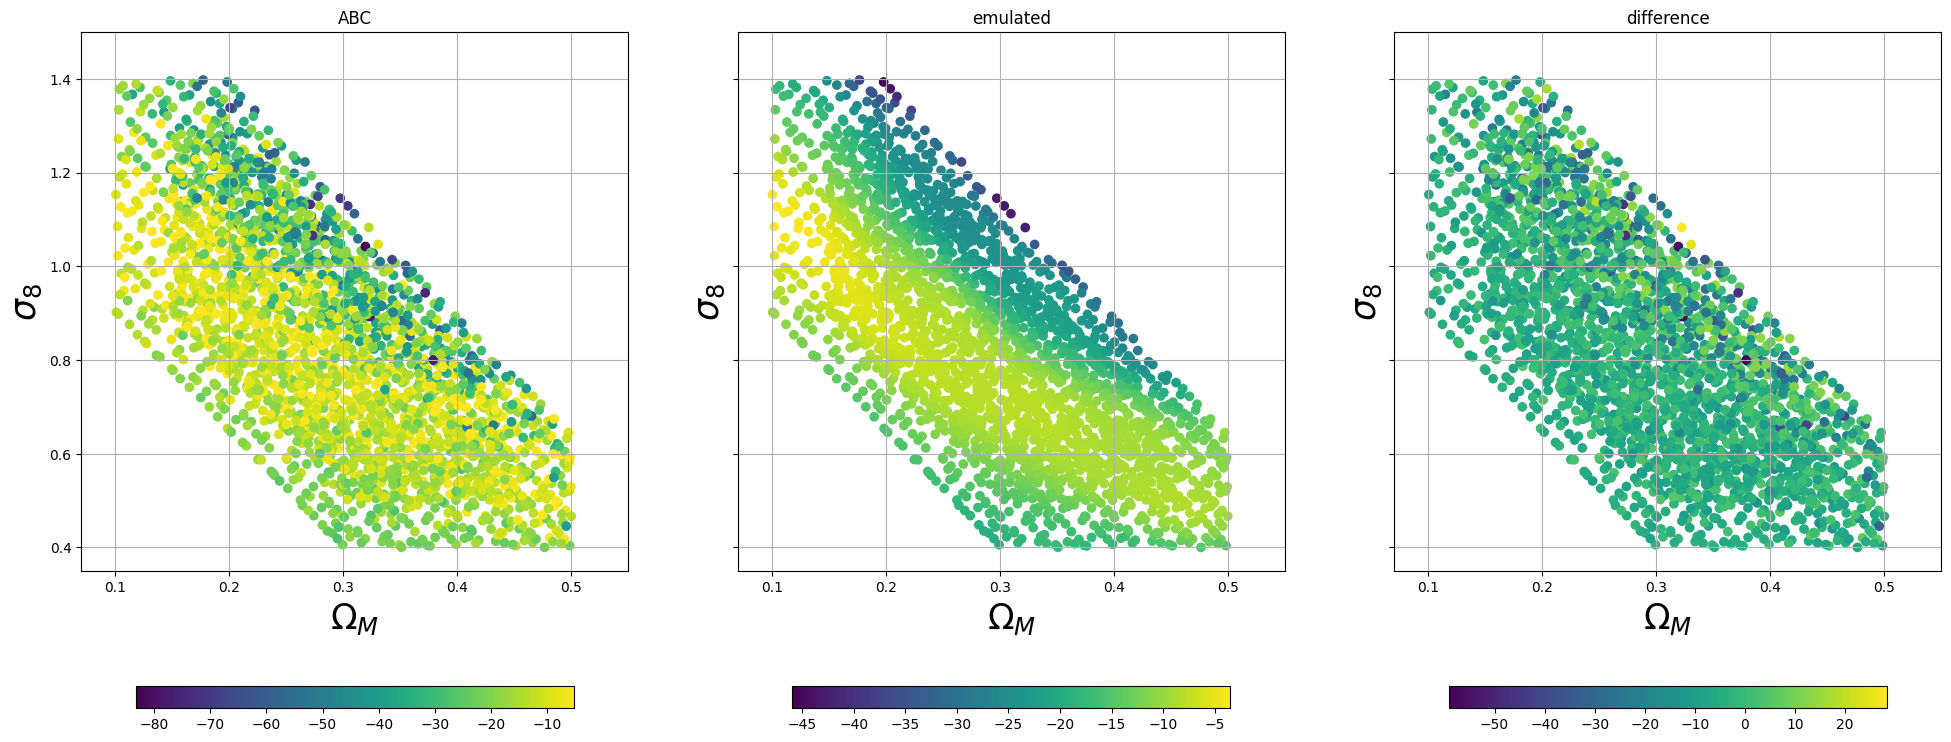

In [18]:
def normalize_Y(Y):
    normalized_prob = Y
    normalized_prob -= np.max(normalized_prob)
    normalized_prob = np.exp(normalized_prob)
    normalized_prob /= np.sum(normalized_prob) 
    
    return normalized_prob

fig, ax = plt.subplots(figsize=(24,10), ncols=3, sharex=True, sharey=True)

# original
original = np.log(normalize_Y(Y_init[:,0]))
im = ax[0].scatter(Om, s8, c=original)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[0].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="ABC")
ax[0].set_xlabel("$\Omega_M$", fontsize=25)
ax[0].set_ylabel("$\sigma_8$", fontsize=25)
ax[0].grid(True)

# emulated
emulated = np.squeeze(np.log(normalize_Y(emu(X_init))))
im = ax[1].scatter(Om, s8, c=emulated)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[1].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="emulated")
ax[1].set_xlabel("$\Omega_M$", fontsize=25)
ax[1].set_ylabel("$\sigma_8$", fontsize=25)
ax[1].grid(True)

# difference
im = ax[2].scatter(Om, s8, c=original - emulated)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[2].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="difference")
ax[2].set_xlabel("$\Omega_M$", fontsize=25)
ax[2].set_ylabel("$\sigma_8$", fontsize=25)
ax[2].grid(True)


# Run the MCMC

In [19]:
log_posterior = lambda X: prior.log_posterior(X, emu(X), params=params, conf=conf)

In [20]:
# emcee setup
np.random.seed(42)

nwalkers = 1024
ndim = len(params)
p0 = np.random.normal(loc=parameters.get_fiducials(params), scale=1e-3, size=(nwalkers, ndim))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=params))) 

Initial values in prior:  True


In [21]:
# sample burn in
sampler = EnsembleSampler(nwalkers, ndim, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()
# run the actual chain
sampler.run_mcmc(state, 1000, progress=True); 

100%|██████████| 1000/1000 [01:11<00:00, 14.00it/s]


In [22]:
samples = sampler.get_chain(flat=True)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

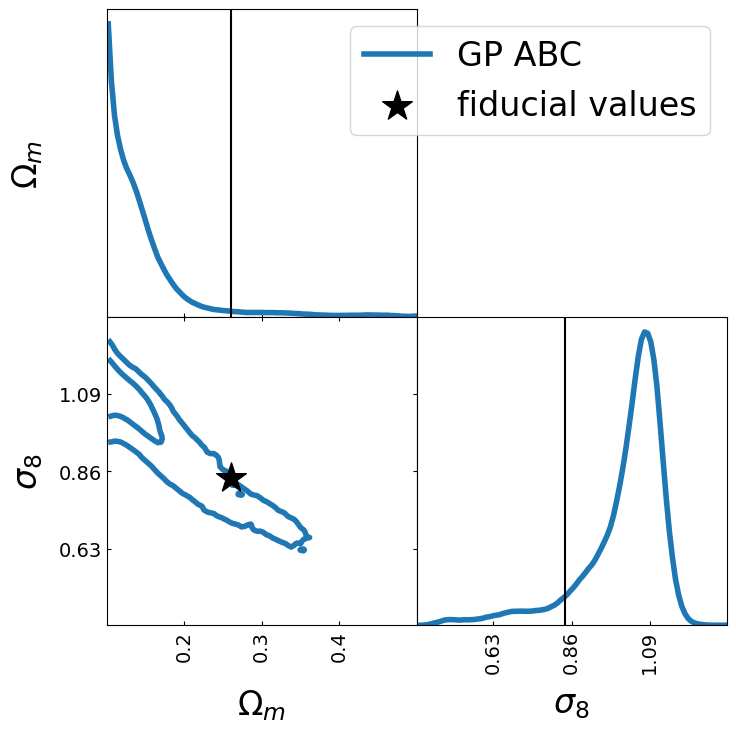

In [23]:
tri = TriangleChain(labels=param_labels, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})
tri.contour_cl(samples, names=params, label="GP ABC")
tri.scatter(
    fiducial,
    label="fiducial values",
    plot_histograms_1D=False,
    color="k",
    show_legend=True,
    scatter_vline_1D=True,
);